# 0. Import Modules

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:42:46_Pacific_Standard_Time_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
!nvidia-smi

Tue Sep 23 16:53:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 33%   35C    P8             12W /  285W |    3039MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Train

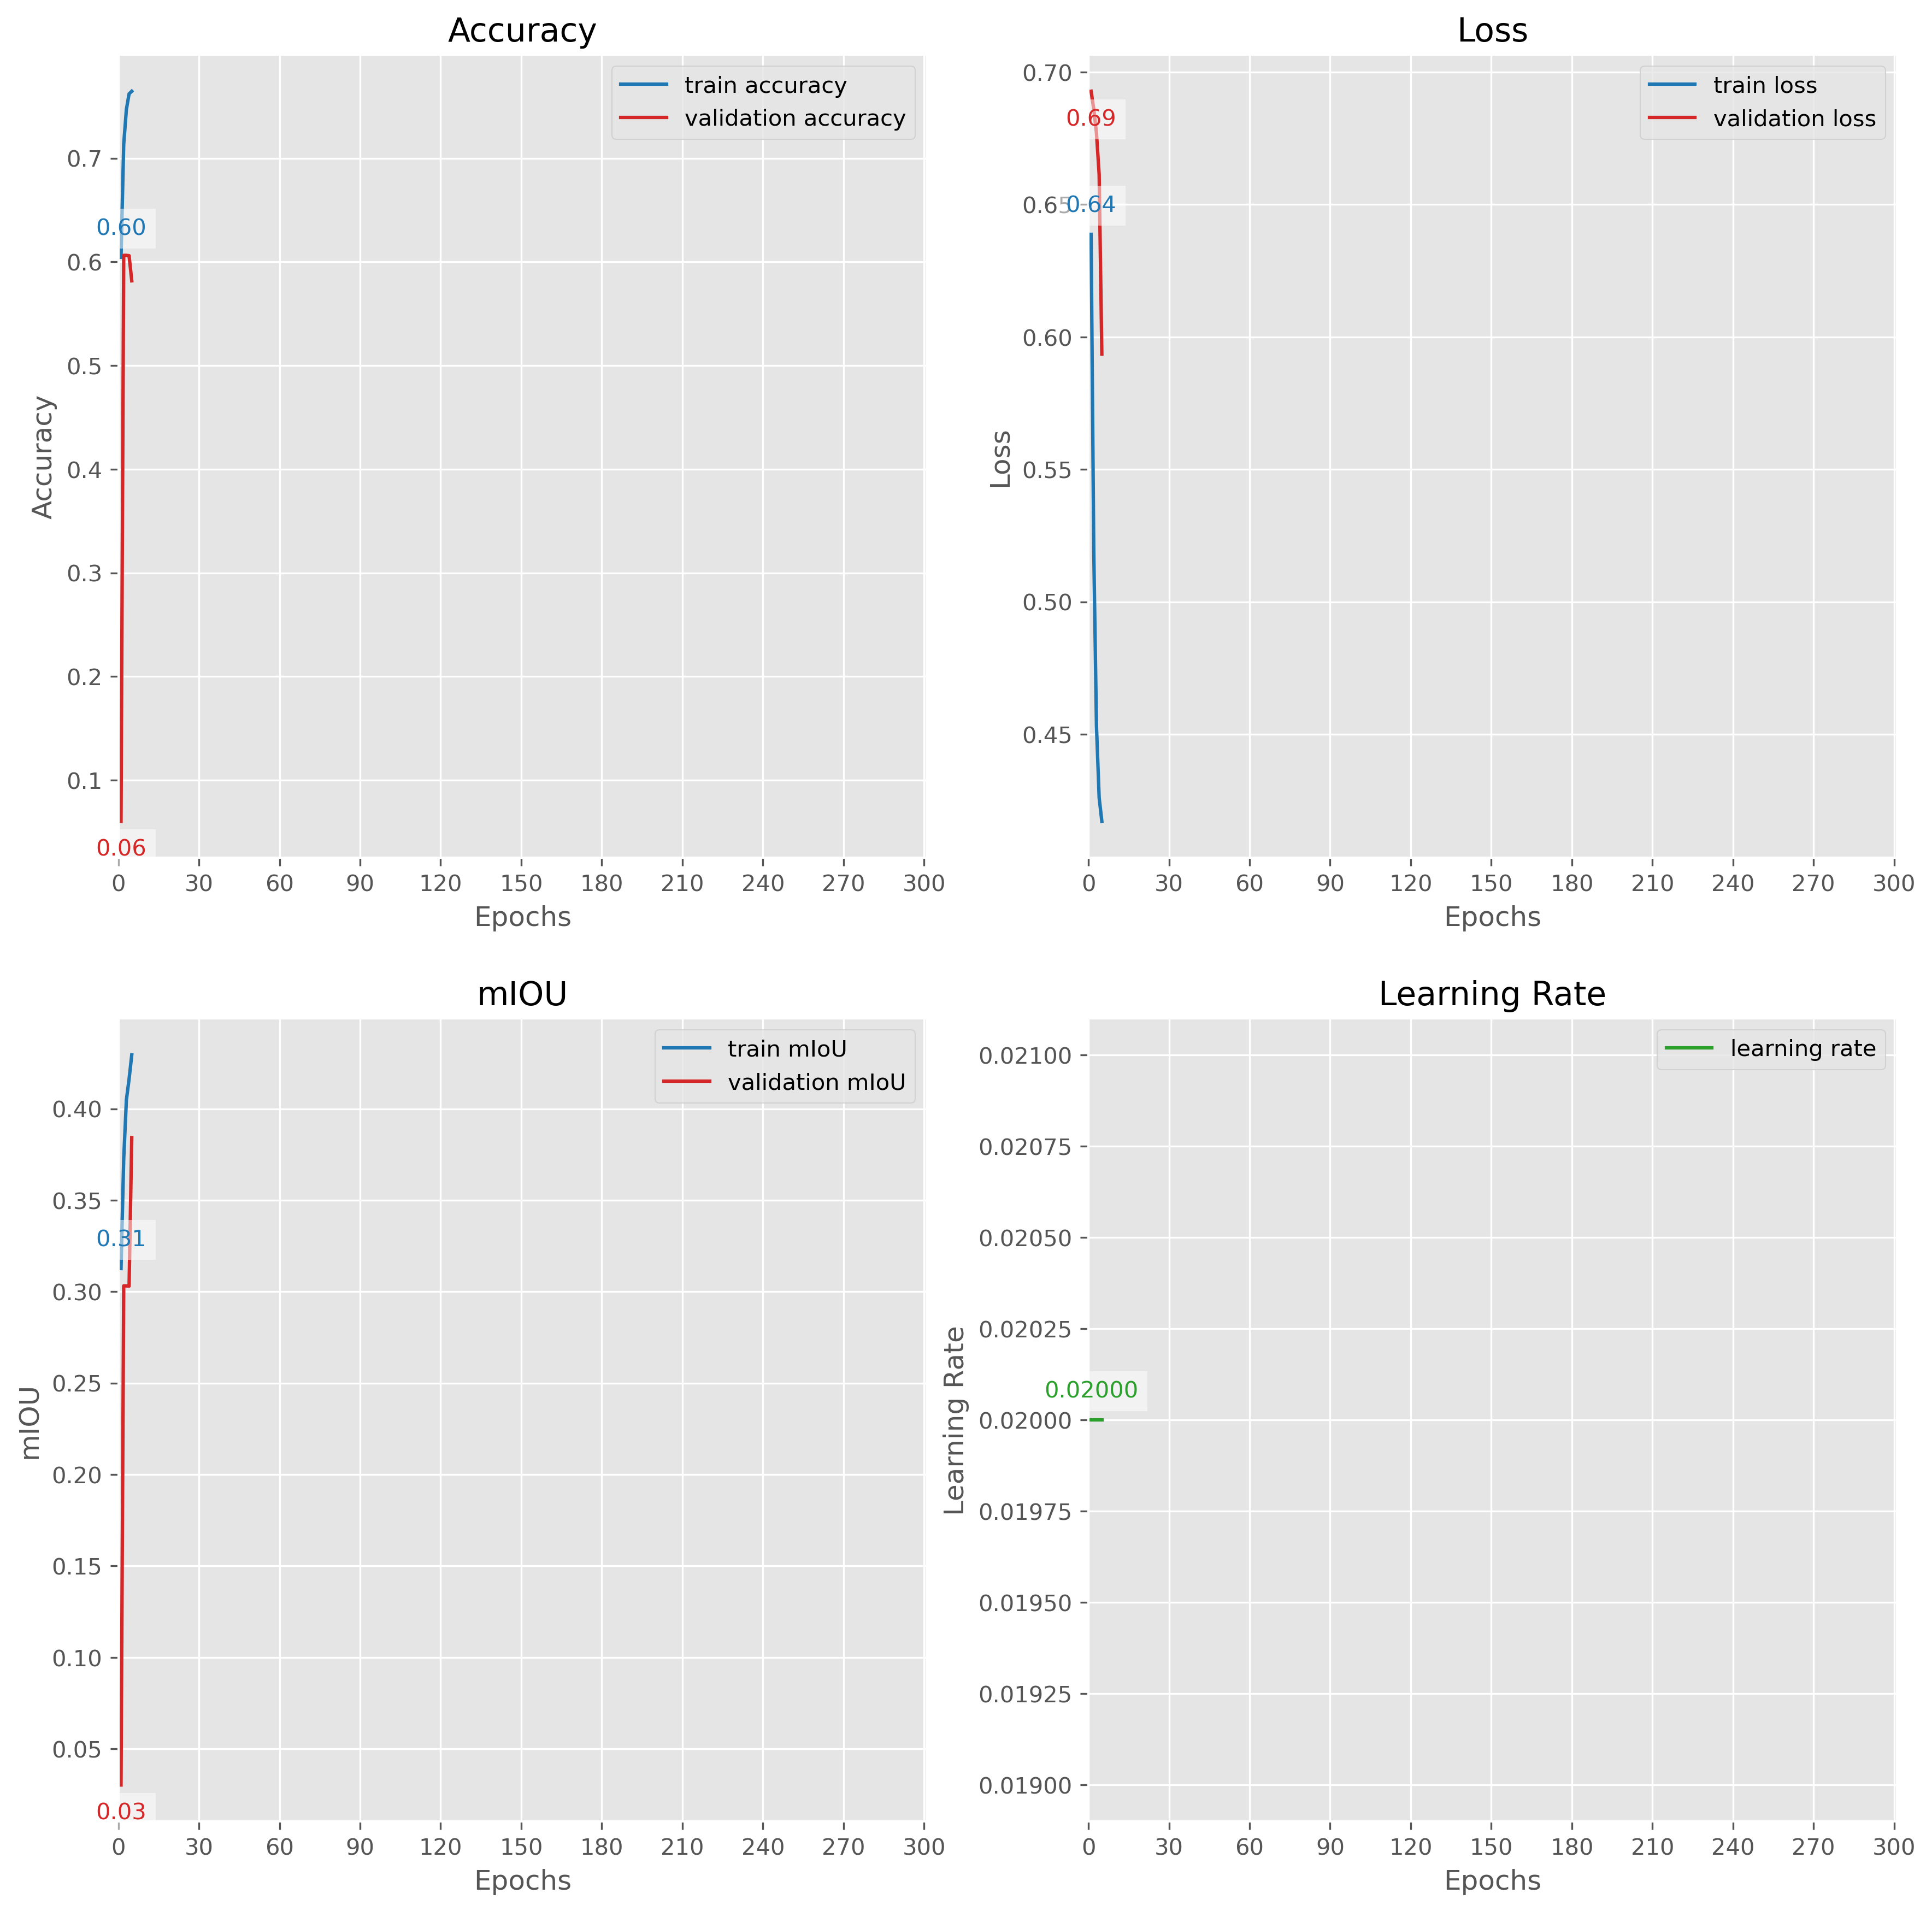

KeyboardInterrupt: 

In [4]:
import os
import random
import shutil
import rasterio
import geopandas as gpd

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
torch.__version__

from config.paths import use
from raster.utils import get_num_bands
from utils.helper_functions import list_files, makedirs

from unet_2.src.model import UNet
from unet_2.src.engine import train_model
from unet_2.src.utils import SaveBestModel, SaveBestModelIOU, load_model
from unet_2.src.datasets import get_images, get_dataset, get_data_loaders
from unet_2.src.config import ALL_CLASSES, LABEL_COLORS_LIST, DEVICE, CLASS_WEIGHTS, MAIRE_WEIGHT
from unet_2.preprocessing import rasterize_vector, tile_image, distribute_files, clip_geotiffs, distribute_files_with_target_balance



list_reserves = [['KAU']]

for reserves in list_reserves:
    tile_size = 576

    base_dataset_name = f"TEST_{'_'.join(reserves)}"

    # Final output directory for the training dataset only
    combined_dataset_dir = os.path.join('../../5_0_unet/april_confirm', base_dataset_name)
    training_dataset_dir = os.path.join(combined_dataset_dir, 'training_dataset')

    if not os.path.exists(training_dataset_dir):

        # Temporary merge directory for distribution
        temp_merge_dir = os.path.join(combined_dataset_dir, 'temp_merge')
        temp_images_dir = os.path.join(temp_merge_dir, f'aerial_{tile_size}')
        temp_labels_dir = os.path.join(temp_merge_dir, f'label_{tile_size}')
        makedirs(temp_images_dir)
        makedirs(temp_labels_dir)

        for r in use(reserves):
            label_gpkg = os.path.join(r.GIS, 'swamp_maire_poly_april.gpkg')
            label_layer = 'maire_poly_ms'
            training_zone_gpkg = os.path.join(r.GIS, 'bbox.gpkg')
            training_zone_layer = 'unet_training_zone'
            #bands = [r.P_MS_RE, r.P_MS_NIR, r.P_IND_RENDVI] #, r.P_MS_SIPI, r.P_MS_GRI, r.P_MS_MRESR, r.P_MS_MCARI]
            #bands = [r.P_RGB_R, r.P_RGB_G, r.P_RGB_B]
            

            bands = list_files(os.path.join(r.P_IND, 'april_confirm'), '_uint8.tif')
            # ['../../3_0_data/limited_extent/B_kauri_glen/B_processed/indices/april_confirm/g_uint8.tif',
            #          '../../3_0_data/limited_extent/B_kauri_glen/B_processed/ms/april_confirm/r_uint8.tif',
            #          '../../3_0_data/limited_extent/B_kauri_glen/B_processed/ms/april_confirm/re_uint8.tif',
            #          '../../3_0_data/limited_extent/B_kauri_glen/B_processed/ms/april_confirm/nir_uint8.tif']
            #print(bands)
            rasterized_label = os.path.join(r.DS_UNET, 'april_confirm', 'maire.tif')

            # Rasterize labels
            rasterized = rasterize_vector(label_gpkg, label_layer, bands[0], rasterized_label, 8192, training_zone_gpkg, training_zone_layer)

            # Reserve-specific output directories
            reserve_image_dir = os.path.join(r.DS_UNET, 'april_confirm', base_dataset_name, f'aerial_{tile_size}')
            reserve_label_dir = os.path.join(r.DS_UNET, 'april_confirm', base_dataset_name, f'label_{tile_size}')
            makedirs(reserve_image_dir, exist_ok=True)
            makedirs(reserve_label_dir, exist_ok=True)

            # Tile multispectral images
            tile_image(
                gdf_path=training_zone_gpkg,
                layer=training_zone_layer,
                tif_paths=bands,
                output_dir=reserve_image_dir,
                file_prefix=f'{r.name}_',
                tile_size=tile_size,
                clear_dir=True
            )

            # Clip rasterized label to match image tiles
            clip_geotiffs(
                rasterized_label,
                reference_dir=reserve_image_dir,
                output_dir=reserve_label_dir
            )

            # Link tiles and labels into temp merge dir
            for f in os.listdir(reserve_image_dir):
                src = os.path.join(reserve_image_dir, f)
                dst = os.path.join(temp_images_dir, f)
                if not os.path.exists(dst):
                    os.link(src, dst)

            for f in os.listdir(reserve_label_dir):
                src = os.path.join(reserve_label_dir, f)
                dst = os.path.join(temp_labels_dir, f)
                if not os.path.exists(dst):
                    os.link(src, dst)

        # Distribute the combined dataset
        distribute_files_with_target_balance(
            dataset_dir=temp_merge_dir,
            folders=['train', 'valid'],
            distribution=[0.8, 0.2],
            image_folder=f'aerial_{tile_size}',
            label_folder=f'label_{tile_size}',
            ignore_nomatch=False,
            out_dir=training_dataset_dir
        )

        # Clean up temp merge dir
        shutil.rmtree(temp_merge_dir)



    seed = 42
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    epochs = 300
    lr = 0.02
    batch_size = 2
    img_size = None
    use_scheduler = True


    model_name = fr"outputs_1_{int(MAIRE_WEIGHT)}_lr_{str(lr)}"

    out_dir = os.path.join(combined_dataset_dir, model_name)
    makedirs(out_dir, delete_if_exists=True, exist_ok=True)
    in_channels = get_num_bands(list_files(combined_dataset_dir, '.tif', True)[0])

    model = UNet(in_channels=in_channels , num_classes=len(ALL_CLASSES)).to(DEVICE)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    train_images, train_masks, valid_images, valid_masks = get_images(root_path=training_dataset_dir)
    classes_to_train = ALL_CLASSES

    train_dataset, valid_dataset = get_dataset(
        train_images, train_masks, valid_images, valid_masks,
        ALL_CLASSES, classes_to_train, LABEL_COLORS_LIST, img_size=img_size
    )

    train_dataloader, valid_dataloader = get_data_loaders(train_dataset, valid_dataset, batch_size=batch_size)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20, threshold=0.00001, threshold_mode='rel', cooldown=0, min_lr=0, eps=1e-08)

    state = train_model(model, train_dataset, train_dataloader, valid_dataset, valid_dataloader, optimizer, criterion, scheduler, epochs, out_dir)



# 2. Load Training Dataset

## 2.1 Import packages, functions and variables

# 2 Set parameters and Train Model

## 3.1 Alternatively continue from a checkpoint

In [1]:
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# To resume training from a checkpoint
model_path = os.path.join(out_dir, 'last_model.pth')
model, criterion, state, optimizer = load_model(model_path, optimizer)

epochs = 18 #total amount of epochs to train the model (previous epochs + new epochs)

# Continue training from the loaded state
state = train_model(model, train_dataset, train_dataloader, valid_dataset, valid_dataloader, optimizer, criterion, scheduler, epochs, out_dir, use_scheduler=True, patience=20, state=state)

NameError: name 'torch' is not defined

# 5 Run model in inference

In [4]:
from unet_2.src.engine import make_predictions
from unet_2.postprocessing import copy_metadata, merge_geotiffs
from config.paths import use
from unet.preprocessing import tile_image

list_reserves = [['KAU']]

for reserves in list_reserves:
# model_name = fr"outputs_1_10_lr_{str(lr).split('.')[1]}"
    model_type = 'best_model_iou'
    #model_type = 'last_model'
    #base_dataset_name = f"RE_NIR_RENDVI_{'_'.join(reserves)}"
    model_path =  fr'../../5_0_unet/april_confirm/{base_dataset_name}/{model_name}/{model_type}.pth'
    
    #reserves = ['ESK', 'KAU', 'BUS', 'HAM', 'WAI']

    for r in use(reserves):

        tile_size = 576
        training_zone_gpkg = os.path.join(r.GIS, 'bbox.gpkg')
        training_zone_layer = 'bbox'
        #bands = [r.P_MS_RE, r.P_MS_NIR, r.P_IND_RENDVI]#, r.P_MS_SIPI, r.P_MS_GRI, r.P_MS_MRESR, r.P_MS_MCARI]
        #bands = list_files(r.P_IND, '_uint8.tif') + bands
        # bands = ['../../3_0_data/limited_extent/B_kauri_glen/B_processed/ms/april_confirm/g_uint8.tif',
        #             '../../3_0_data/limited_extent/B_kauri_glen/B_processed/ms/april_confirm/r_uint8.tif',
        #             '../../3_0_data/limited_extent/B_kauri_glen/B_processed/ms/april_confirm/re_uint8.tif',
        #             '../../3_0_data/limited_extent/B_kauri_glen/B_processed/ms/april_confirm/nir_uint8.tif']
        bands = list_files(os.path.join(r.P_IND, 'april_confirm'), '_uint8.tif')
        # Reserve-specific output directories
        out_dir = os.path.join(r.DS_UNET, 'april_confirm', base_dataset_name, model_name)
        tiles_dir = os.path.join(out_dir, f'aerial_{tile_size}')
        preds_dir = os.path.join(out_dir, 'predictions')
        os.makedirs(tiles_dir, exist_ok=True)
        os.makedirs(preds_dir, exist_ok=True)

        # Tile multispectral images
        tile_image(
            gdf_path=training_zone_gpkg,
            layer=training_zone_layer,
            tif_paths=bands,
            output_dir=tiles_dir,
            file_prefix=f'{r.name}_',
            tile_size=tile_size,
            clear_dir=True
        )




        pred_tiles_dir = os.path.join(preds_dir, 'tiles')
        out_tif = os.path.join(preds_dir, f'{model_type}.tif')
        make_predictions(tiles_dir, model_path, pred_tiles_dir)
        copy_metadata(rgb_dir=tiles_dir, gray_dir=pred_tiles_dir)
        # merge the individual tiles to retrieve a single output file
        merge_geotiffs(pred_tiles_dir, out_tif)


Processing Reserves: 100%|██████████| 1/1 [00:11<00:00, 11.70s/it]
